In [44]:
import tensorflow as tf
tf.keras.backend.clear_session()

<a href="https://colab.research.google.com/github/devpatel0005/Stock-Sentiment-Analysis-based-on-News/blob/main/Stock_Sentiment_Analysis_Using_LSTM_based_on_News.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dense, Embedding, Dropout, BatchNormalization, Bidirectional, LSTM,GRU
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import nltk
import re
from nltk.stem import PorterStemmer,WordNetLemmatizer
from nltk.corpus import stopwords
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score


In [46]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tvard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tvard\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

- The data set in consideration is a combination of the world news and stock price shifts available on Kaggle.
- There are 25 columns of top news headlines for each day in the data frame.
Data ranges from 2008 to 2016 and the data from 2000 to 2008 was scrapped from Yahoo finance.
- Labels are based on the Dow Jones Industrial Average stock index.
- Class 1 → the stock price increased.
- Class 0 → the stock price stayed the same or decreased.

In [47]:
import pandas as pd
df=pd.read_csv('Data.csv',encoding='ISO-8859-1')

df.sample(5)

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
1851,2007-07-27,0,Wenger warns young Gunners he will not take se...,"Size matters, says Given, as he urges signings...",Nani's star rises in the east as United head h...,How do you tell good from bad?,Redknapp tells Quinn to butt out,Strachan close to new Celtic deal,Heinze's solicitor calls for arbitration to se...,'I can now call myself an Arsenal fan. I will ...,...,"Rugby league: Forget Vainikolo, Bulls' new vol...",Rugby league: Long resumes goalkicking role fo...,Motor sport: Harris earns respect of his peers...,Golf: Stenson disqualified for losing count as...,Horse racing: Maraahel can come good at last,Cricket: England rock as sultans of swing leav...,Golf: Wie under par at last,Cricket: Trent Bridge to undergo £8.2m revamp,Cricket: Cook looks to seamers,Chess
1873,2007-08-28,0,Stephen Bates: People,Tough Diamond who became a real-life master of...,Interview: 'Dr Nick Edwards',Estate hits back at Widdecombe,Nurses loth to report abuse of the elderly,Mole gang's plot to dig for cash goes awry,I might as well have been his briefcase,Carling Cup: Tie halted after Leicester player...,...,Digger: Candidate Morris has a message for cri...,Champions League qualifying: Celtic looking to...,"I'm not coming here to be a hero, says contrit...",Carling Cup: Luton 3-0 Sunderland,The big debate: should the FA Cup offer a Cham...,Rugby union:,Rugby union: Robinson's extra-time,Cricket: Pietersen feels the force of the new ...,How a wuss in boots became king of the mountains,Cricket: Battling Walker rides his luck as Ken...
2190,2008-11-28,1,"b""Mumbai photographer: I wish I'd had a gun, n...","b""Let's try not to panic... (Pic)""",b'Hemp: Swiss citizens vote tomorrow to legali...,"b""What Happens To You After You Get Caught Spy...",b'Mumbai terrorists recruited with promise of ...,"b'Japanese Told to Work Less, Have More Sex '",b'India uncovers Hindu terror group that carri...,"b'Deepak Chopra agrees: Washington, not Al-Qae...",...,b'Conservative Canadian Government May Fall',b'President Zardari: Theres a little bit of In...,"b""Inadequate Sex Blamed for Increased Crime Am...","b'""What They Hate About Mumbai"" - a Mumbaikar\...",b' Patrick Cockburn: Pakistan is the root of t...,b'Indian force kill last gunman in Mumbai',b'Chinese internet giant sacks staff over paid...,"b'Dutch ban on ""magic"" mushrooms to take effect'","b'How to Deal with Pirates: ""We shall offer th...",b'The Ministry of Defence turned large parts o...
1363,2005-08-04,1,Day of mindless fun for A-level washouts,Costly admissions,River tests expose cocaine use,Interest rate cut is first in two years,Do I wait for my car or cut my losses?,Woman shot dead in arson attack,£77m winner cleaves to the quiet life,Walker suspects in custody after flight,...,The disappeared,Iran sends in troops to crush border unrest,Speedy extradition hearing in Rome,Leaders plead for calm as Sudan riot toll rise...,Going for a song: one orchestra,Abbey's ancient treasure revealed,"Time and Time Again, Stephen Joseph, Scarborough","Starsailor, Somerset House, London","London Sinfonietta/Masson, Royal Albert Hall, ...","The Fatback Band, Jazz Cafe, London"
2014,2008-03-20,0,Verizon wins in US wireless auction; Google loses,Joe Cole provides the beauty as Capello's eyes...,"Simon Davies (of Privacy International, and 80...",Stingray attack leads to woman's death,McCain campaign suspends aide for circulating ...,Iran's forgotten religions,McCain's links to Scottish king shot down by e...,The Iraq legacy: a diplomatic surge,...,ITV hangs on to Champions League live rights,City whispers,MP Conway will not face police investigation,SPL agrees Gretna rescue package,Banking chiefs ask King for more money,Unscientific American,Timeline: Anglo-Russian relations,Music Weekly podcast: Long Blondes interview,Cramer gets a run for his money,Video: Pudcast: Toffee apple tarts


- ISO-8859-1, also known as Latin-1, is a character encoding standard that maps 256 different characters to numerical values. It's one of the most common encodings used for text in Western European languages

In [48]:
df.shape

(4101, 27)

# Splitting the Data into train and test

In [49]:
df['Date']

0       2000-01-03
1       2000-01-04
2       2000-01-05
3       2000-01-06
4       2000-01-07
           ...    
4096    2016-06-27
4097    2016-06-28
4098    2016-06-29
4099    2016-06-30
4100    2016-07-01
Name: Date, Length: 4101, dtype: object

In [50]:
train=df[df['Date']<'20150101']
test=df[df['Date']>'20141231']

Here the data before 2015 is test and after it is considered as trianing data

In [51]:
test.shape

(378, 27)

In [52]:
train.shape

(3975, 27)

In [53]:
data=train.iloc[:,2:27]
#renaming the columns for ease of acess
new_index=[str(i) for i in range(25)] #since our data has 25 columns top 25 news headlines for stock
data.columns=new_index

In [54]:
data

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,A 'hindrance to operations': extracts from the...,Scorecard,Hughes' instant hit buoys Blues,Jack gets his skates on at ice-cold Alex,Chaos as Maracana builds up for United,Depleted Leicester prevail as Elliott spoils E...,Hungry Spurs sense rich pickings,Gunners so wide of an easy target,Derby raise a glass to Strupar's debut double,"Southgate strikes, Leeds pay the penalty",...,Flintoff injury piles on woe for England,Hunters threaten Jospin with new battle of the...,Kohl's successor drawn into scandal,The difference between men and women,"Sara Denver, nurse turned solicitor",Diana's landmine crusade put Tories in a panic,Yeltsin's resignation caught opposition flat-f...,Russian roulette,Sold out,Recovering a title
1,Scorecard,The best lake scene,Leader: German sleaze inquiry,"Cheerio, boyo",The main recommendations,Has Cubie killed fees?,Has Cubie killed fees?,Has Cubie killed fees?,Hopkins 'furious' at Foster's lack of Hannibal...,Has Cubie killed fees?,...,On the critical list,The timing of their lives,Dear doctor,Irish court halts IRA man's extradition to Nor...,Burundi peace initiative fades after rebels re...,PE points the way forward to the ECB,Campaigners keep up pressure on Nazi war crime...,Jane Ratcliffe,Yet more things you wouldn't know without the ...,Millennium bug fails to bite
2,Coventry caught on counter by Flo,United's rivals on the road to Rio,Thatcher issues defence before trial by video,Police help Smith lay down the law at Everton,Tale of Trautmann bears two more retellings,England on the rack,Pakistan retaliate with call for video of Walsh,Cullinan continues his Cape monopoly,McGrath puts India out of their misery,Blair Witch bandwagon rolls on,...,South Melbourne (Australia),Necaxa (Mexico),Real Madrid (Spain),Raja Casablanca (Morocco),Corinthians (Brazil),Tony's pet project,Al Nassr (Saudi Arabia),Ideal Holmes show,Pinochet leaves hospital after tests,Useful links
3,Pilgrim knows how to progress,Thatcher facing ban,McIlroy calls for Irish fighting spirit,Leicester bin stadium blueprint,United braced for Mexican wave,"Auntie back in fashion, even if the dress look...",Shoaib appeal goes to the top,Hussain hurt by 'shambles' but lays blame on e...,England's decade of disasters,Revenge is sweet for jubilant Cronje,...,Putin admits Yeltsin quit to give him a head s...,BBC worst hit as digital TV begins to bite,How much can you pay for...,Christmas glitches,"Upending a table, Chopping a line and Scoring ...","Scientific evidence 'unreliable', defence claims",Fusco wins judicial review in extradition case,Rebels thwart Russian advance,Blair orders shake-up of failing NHS,Lessons of law's hard heart
4,Hitches and Horlocks,Beckham off but United survive,Breast cancer screening,Alan Parker,Guardian readers: are you all whingers?,Hollywood Beyond,Ashes and diamonds,Whingers - a formidable minority,Alan Parker - part two,"Thuggery, Toxins and Ties",...,Most everywhere: UDIs,Most wanted: Chloe lunettes,Return of the cane 'completely off the agenda',From Sleepy Hollow to Greeneland,Blunkett outlines vision for over 11s,"Embattled Dobson attacks 'play now, pay later'...",Doom and the Dome,What is the north-south divide?,Aitken released from jail,Gone aloft
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3970,"Brazil declares emergency after 2,400 babies a...",Scientists find big 1500-yr-old Viking settlem...,Paris attacks: Belgian police arrest ninth sus...,Wiretapping reveals communication between Turk...,Russia airstrikes: Hundreds of Syrian civilans...,Pakistan changes neutral position on Syrian Ci...,North Korean diplomat arrested in South Africa...,German teachers want 'Mein Kampf' on syllabus,North Korea slave force earns Kim Jong Un regi...,"50,000 Yemeni Forces Preparing to Attack Saudi...",...,Report on sexual exploitation and abuse by pea...,Baby girl dies after X-president's son's staff...,China smog sparks r

# Converting the headlines into lowercase

In [55]:
for index in new_index:
  data[index]=data[index].str.lower()

In [56]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,a 'hindrance to operations': extracts from the...,scorecard,hughes' instant hit buoys blues,jack gets his skates on at ice-cold alex,chaos as maracana builds up for united,depleted leicester prevail as elliott spoils e...,hungry spurs sense rich pickings,gunners so wide of an easy target,derby raise a glass to strupar's debut double,"southgate strikes, leeds pay the penalty",...,flintoff injury piles on woe for england,hunters threaten jospin with new battle of the...,kohl's successor drawn into scandal,the difference between men and women,"sara denver, nurse turned solicitor",diana's landmine crusade put tories in a panic,yeltsin's resignation caught opposition flat-f...,russian roulette,sold out,recovering a title
1,scorecard,the best lake scene,leader: german sleaze inquiry,"cheerio, boyo",the main recommendations,has cubie killed fees?,has cubie killed fees?,has cubie killed fees?,hopkins 'furious' at foster's lack of hannibal...,has cubie killed fees?,...,on the critical list,the timing of their lives,dear doctor,irish court halts ira man's extradition to nor...,burundi peace initiative fades after rebels re...,pe points the way forward to the ecb,campaigners keep up pressure on nazi war crime...,jane ratcliffe,yet more things you wouldn't know without the ...,millennium bug fails to bite
2,coventry caught on counter by flo,united's rivals on the road to rio,thatcher issues defence before trial by video,police help smith lay down the law at everton,tale of trautmann bears two more retellings,england on the rack,pakistan retaliate with call for video of walsh,cullinan continues his cape monopoly,mcgrath puts india out of their misery,blair witch bandwagon rolls on,...,south melbourne (australia),necaxa (mexico),real madrid (spain),raja casablanca (morocco),corinthians (brazil),tony's pet project,al nassr (saudi arabia),ideal holmes show,pinochet leaves hospital after tests,useful links
3,pilgrim knows how to progress,thatcher facing ban,mcilroy calls for irish fighting spirit,leicester bin stadium blueprint,united braced for mexican wave,"auntie back in fashion, even if the dress look...",shoaib appeal goes to the top,hussain hurt by 'shambles' but lays blame on e...,england's decade of disasters,revenge is sweet for jubilant cronje,...,putin admits yeltsin quit to give him a head s...,bbc worst hit as digital tv begins to bite,how much can you pay for...,christmas glitches,"upending a table, chopping a line and scoring ...","scientific evidence 'unreliable', defence claims",fusco wins judicial review in extradition case,rebels thwart russian advance,blair orders shake-up of failing nhs,lessons of law's hard heart
4,hitches and horlocks,beckham off but united survive,breast cancer screening,alan parker,guardian readers: are you all whingers?,hollywood beyond,ashes and diamonds,whingers - a formidable minority,alan parker - part two,"thuggery, toxins and ties",...,most everywhere: udis,most wanted: chloe lunettes,return of the cane 'completely off the agenda',from sleepy hollow to greeneland,blunkett outlines vision for over 11s,"embattled dobson attacks 'play now, pay later'...",doom and the dome,what is the north-south divide?,aitken released from jail,gone aloft


- Now for implementing the NLP techniques like Bag of Words or Tf-IDF we need to combine these all columns of a row into one single paragraph for every row

In [57]:
data.index

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       3965, 3966, 3967, 3968, 3969, 3970, 3971, 3972, 3973, 3974],
      dtype='int64', length=3975)

In [58]:
headlines=[]
for rows in range(0,len(data.index)):
  headlines.append(' '.join(str(x) for x in data.iloc[rows,0:25])) # columns are from 0 to 24 so we mentioned 0:25 to include all

In [59]:
headlines[1]

"scorecard the best lake scene leader: german sleaze inquiry cheerio, boyo the main recommendations has cubie killed fees? has cubie killed fees? has cubie killed fees? hopkins 'furious' at foster's lack of hannibal appetite has cubie killed fees? a tale of two tails i say what i like and i like what i say elbows, eyes and nipples task force to assess risk of asteroid collision how i found myself at last on the critical list the timing of their lives dear doctor irish court halts ira man's extradition to northern ireland burundi peace initiative fades after rebels reject mandela as mediator pe points the way forward to the ecb campaigners keep up pressure on nazi war crimes suspect jane ratcliffe yet more things you wouldn't know without the movies millennium bug fails to bite"

- Now for every row we have merged  of each and every index the news into one single headline

In [60]:
ps=WordNetLemmatizer()

In [61]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

Num GPUs Available: 1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# News Preprocessing

In [62]:
stop_words = set(stopwords.words('english'))  # load once
stem_headlines = []

for paragraph in headlines:
    sentences = nltk.sent_tokenize(paragraph)
    review=[]
    for i in range(len(sentences)):
        review = re.sub('[^a-zA-Z]', ' ', sentences[i])
        review = review.lower()
        review = review.split()
        review = [ps.lemmatize(word) for word in review if not word in stop_words]
        #review = ' '.join(review)

    stem_headlines.append(' '.join(review))


In [63]:
stem_headlines[1]

'tale two tail say like like say elbow eye nipple task force assess risk asteroid collision found last critical list timing life dear doctor irish court halt ira man extradition northern ireland burundi peace initiative fade rebel reject mandela mediator pe point way forward ecb campaigner keep pressure nazi war crime suspect jane ratcliffe yet thing know without movie millennium bug fails bite'

In [64]:
all_words = set()
for headline in stem_headlines:
  for word in headline.split():
    all_words.add(word)
voc_size = len(all_words) + 1

print(f"Calculated vocabulary size: {voc_size}")

Calculated vocabulary size: 24805


# Embedding Layer approach

Here calculated the vocabulary size(basically the dictionary size) which is necessary for the Embedding layer input

In [65]:
onehot_repr = [one_hot(words, voc_size) for words in stem_headlines]
print(f"First one-hot encoded headline: {onehot_repr[0]}")

First one-hot encoded headline: [23168, 904, 16508, 9924, 2798, 3365, 6591, 16899, 3859, 11272, 2380, 1704, 16445, 1877, 2242, 8060, 11303, 3044, 8854, 8599, 19020, 16365, 15471, 15525, 24740, 4738, 6290, 9184, 6572, 9510, 16326, 9032, 21536, 20871, 14719, 13071, 8371, 19584, 8151, 5308, 5245, 8059, 16998, 18995, 12222, 9456, 22772, 21602, 17865, 8443, 10214, 22893, 11460, 4571, 9184, 4267, 6988, 15684, 7709, 15692, 23933, 11641, 16892, 22989, 9430, 1747, 7320, 22640, 3859, 10872, 10215, 15796, 379, 1296, 19481, 15999, 19770, 21131, 19426, 7189, 19539, 14256, 1420, 14031, 9145, 15550, 15020, 16183, 4540, 3244, 7709, 2854, 3349, 14197, 16927, 24528, 4018, 11667, 21549, 11180, 3620, 226, 10659, 20384, 21134, 13692, 1067, 393, 15105]


to pass into the Embedding layer we need to convert into the numerical form, for that the one_hot_representation will represent each word based on their position in the vocabulary

In [66]:
maxlen = max([len(x) for x in onehot_repr])
print(f"Maximum length of a headline for padding: {maxlen}")

Maximum length of a headline for padding: 278


In [67]:
x = pad_sequences(onehot_repr, padding='pre', maxlen=maxlen)
print(f"Shape of embedded documents after padding: {x.shape}")

Shape of embedded documents after padding: (3975, 278)


In [68]:
y = np.array(train['Label'])

In [69]:
print(pd.Series(y).value_counts())

1    2096
0    1879
Name: count, dtype: int64


In [70]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of x_val: {x_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of x_train: (3180, 278)
Shape of x_val: (795, 278)
Shape of y_train: (3180,)
Shape of y_val: (795,)


With return_sequences=True: The layer returns the full sequence of outputs for all time steps. This is a 3D tensor: (batch_size, timesteps, units). Useful for tasks like sequence-to-sequence prediction or stacking RNN layers.

- Here since the Dense layer expects 2-D shape and the LSTM gives 3-D we turned return_sequences = False to give output in 2_D

# Building the LSTM Model

In [73]:
EMBEDDING_DIM = 50  # it is the vector size for each word in the embedding layer hyperparameter to control model capacity

model = Sequential()
model.add(Embedding(input_dim=voc_size, output_dim=EMBEDDING_DIM))
# model.add(Bidirectional(LSTM(128,return_sequences=True)))
# model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(8,return_sequences=False)))
model.add(Dropout(0.3))
# model.add(Bidirectional(LSTM(32,return_sequences=False)))
# model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, None, 50)          1240250   
                                                                 
 bidirectional (Bidirectiona  (None, 16)               3776      
 l)                                                              
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense (Dense)               (None, 1)                 17        
                                                                 
Total params: 1,244,043
Trainable params: 1,244,043
Non-trainable params: 0
_________________________________________________________________


In [74]:
model.compile(optimizer=Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

In [75]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape

((3180, 278), (3180,), (795, 278), (795,))

- EarlyStopping Callback
This callback stops training early if the model's performance isn't improving, to avoid wasting time and prevent overfitting.
patience=5: If the validation loss doesn't improve for 5 consecutive epochs (training rounds), stop training.
restore_best_weights=True: After stopping, revert the model to the weights from the epoch with the best validation loss

- ReduceLROnPlateau Callback
It's like slowing down the learning pace if the model is stuck, giving it more time to fine-tune without jumping around too much. This often leads to better final performance.


In [76]:

early = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(x_train, y_train,epochs=50,batch_size=64,validation_data=(x_val, y_val),callbacks=[early],verbose=1)

Epoch 1/50
50/50 [==============================] - 4s 46ms/step - loss: 0.6928 - accuracy: 0.5252 - val_loss: 0.6926 - val_accuracy: 0.5170
Epoch 2/50
50/50 [==============================] - 2s 39ms/step - loss: 0.6799 - accuracy: 0.5453 - val_loss: 0.6928 - val_accuracy: 0.5145
Epoch 3/50
50/50 [==============================] - 2s 41ms/step - loss: 0.6154 - accuracy: 0.7274 - val_loss: 0.7107 - val_accuracy: 0.5132
Epoch 4/50
50/50 [==============================] - 2s 38ms/step - loss: 0.4476 - accuracy: 0.8723 - val_loss: 0.8143 - val_accuracy: 0.5220
Epoch 5/50
50/50 [==============================] - 2s 40ms/step - loss: 0.2936 - accuracy: 0.9349 - val_loss: 0.8543 - val_accuracy: 0.5220
Epoch 6/50
50/50 [==============================] - 2s 40ms/step - loss: 0.1972 - accuracy: 0.9670 - val_loss: 0.9631 - val_accuracy: 0.5157
Epoch 7/50
50/50 [==============================] - 2s 43ms/step - loss: 0.1441 - accuracy: 0.9805 - val_loss: 1.1037 - val_accuracy: 0.5145
Epoch 8/50
50

- validation_split is used when we do not have a validation data, but here since we have done the trian test split and created the validation data explicitly we can use validation_data in the fit method

- validation_data - Random split each run (unless seeded), leading to inconsistent results.Controlled: You can ensure it's representative (e.g., stratified, time-ordered).
Better for evaluation: Matches how you evaluate with model.evaluate(x_val, y_val).
Avoids overlap with training data.


# Model Evaluation

In [77]:
print("Train Loss/Accuracy:", model.evaluate(x_train, y_train, verbose=1))
print("Val Loss/Accuracy:  ", model.evaluate(x_val, y_val, verbose=1))
# For test, preprocess first (since test is raw)
x_test = pad_sequences([one_hot(' '.join(str(x) for x in row), voc_size) for row in test.iloc[:,2:27].values], padding='pre', maxlen=maxlen)
y_test = np.array(test['Label'])
print("Test Loss/Accuracy: ", model.evaluate(x_test, y_test, verbose=1))

100/100 [==============================] - 2s 22ms/step - loss: 0.6857 - accuracy: 0.5299
Train Loss/Accuracy: [0.6857344508171082, 0.5298742055892944]
25/25 [==============================] - 1s 22ms/step - loss: 0.6926 - accuracy: 0.5170
Val Loss/Accuracy:   [0.6926047801971436, 0.5169811248779297]
12/12 [==============================] - 0s 23ms/step - loss: 0.6906 - accuracy: 0.5238
Test Loss/Accuracy:  [0.6906426548957825, 0.523809552192688]


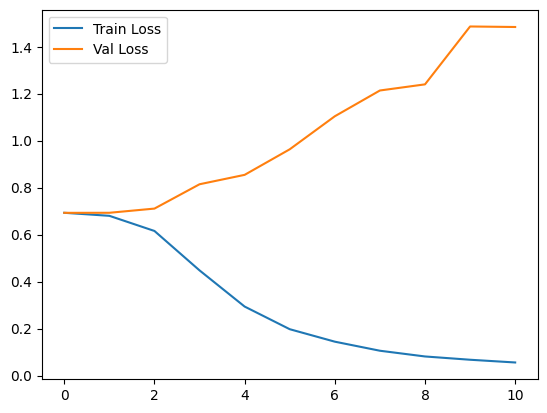

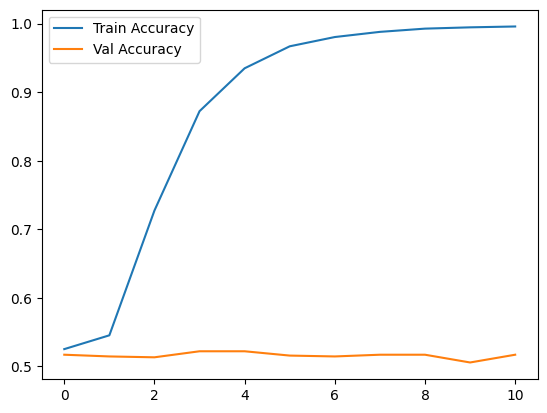

In [78]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

# Random Forest Implementation

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Function to preprocess headlines
def preprocess_headlines(df_subset):
    headlines = [' '.join(str(x) for x in row if str(x) != 'nan') for row in df_subset.iloc[:,2:27].values]
    stem_headlines_subset = []
    for paragraph in headlines:
        review = []
        for word in paragraph.split():
            if word not in stop_words:
                review.append(ps.lemmatize(word))
        stem_headlines_subset.append(' '.join(review))
    return stem_headlines_subset

# Preprocess train and test headlines
stem_headlines_train = preprocess_headlines(train)
stem_headlines_test = preprocess_headlines(test)

y_train = train['Label'].values
y_test = test['Label'].values

# Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(stem_headlines_train)
X_test = vectorizer.transform(stem_headlines_test)

# Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict and evaluate
y_pred = rf.predict(X_test)
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Check training accuracy
y_pred_train = rf.predict(X_train)
print("Random Forest Training Accuracy:", accuracy_score(y_train, y_pred_train))

Random Forest Test Accuracy: 0.8359788359788359
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       186
           1       0.82      0.86      0.84       192

    accuracy                           0.84       378
   macro avg       0.84      0.84      0.84       378
weighted avg       0.84      0.84      0.84       378

Random Forest Training Accuracy: 1.0


In [80]:
# Perform Grid Search CV to tune hyperparameters and prevent overfitting
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

# Evaluate the best model
y_pred_test = best_rf.predict(X_test)
print("Tuned RF Test Accuracy:", accuracy_score(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

y_pred_train = best_rf.predict(X_train)
print("Tuned RF Training Accuracy:", accuracy_score(y_train, y_pred_train))

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Tuned RF Test Accuracy: 0.6084656084656085
              precision    recall  f1-score   support

           0       0.97      0.21      0.35       186
           1       0.57      0.99      0.72       192

    accuracy                           0.61       378
   macro avg       0.77      0.60      0.53       378
weighted avg       0.77      0.61      0.54       378

Tuned RF Training Accuracy: 0.6628930817610063
